In [1]:
import numpy as np
import pandas as pd

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

train = train.drop("Unnamed: 0", axis=1)
test = test.drop("Unnamed: 0", axis=1)

train

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
0,Tata Tiago 1.2 Revotron XZ WO Alloy,Hyderabad,2017,16500,Petrol,Manual,First,23.84 kmpl,1199 CC,84 bhp,5.0,5.00
1,Mahindra TUV 300 2015-2019 mHAWK100 T8 AMT,Kochi,2017,47357,Diesel,Automatic,First,18.49 kmpl,1493 CC,100 bhp,7.0,8.37
2,Skoda Rapid 2013-2016 1.6 MPI Ambition,Mumbai,2014,35000,Petrol,Manual,First,15.0 kmpl,1598 CC,103.52 bhp,5.0,4.50
3,Tata Indica V2 DLS BSII,Jaipur,2007,200000,Diesel,Manual,Second,17.2 kmpl,1396 CC,53.5 bhp,5.0,0.85
4,Tata Manza Club Class Quadrajet90 LX,Mumbai,2013,64000,Diesel,Manual,Second,21.02 kmpl,1248 CC,88.76 bhp,5.0,2.65
...,...,...,...,...,...,...,...,...,...,...,...,...
3745,BMW X5 3.0d,Chennai,2009,150000,Diesel,Automatic,First,11.0 kmpl,2993 CC,235 bhp,5.0,18.75
3746,Mahindra Scorpio 2009-2014 VLX 4WD AT 7S BSIV,Delhi,2012,85000,Diesel,Automatic,First,11.79 kmpl,2179 CC,120 bhp,7.0,6.25
3747,Maruti Wagon R LXI BSII,Ahmedabad,2007,55100,Petrol,Manual,First,18.9 kmpl,998 CC,67.1 bhp,5.0,1.45
3748,Renault Duster 85PS Diesel RxL,Hyderabad,2014,77500,Diesel,Manual,First,20.45 kmpl,1461 CC,83.8 bhp,5.0,6.60


In [2]:
train.dtypes

Name                  object
Location              object
Year                   int64
Kilometers_Driven      int64
Fuel_Type             object
Transmission          object
Owner_Type            object
Mileage               object
Engine                object
Power                 object
Seats                float64
Price                float64
dtype: object

In [2]:
train.dtypes

Name                  object
Location              object
Year                   int64
Kilometers_Driven      int64
Fuel_Type             object
Transmission          object
Owner_Type            object
Mileage               object
Engine                object
Power                 object
Seats                float64
Price                float64
dtype: object

In [3]:
train["Mileage"] = pd.to_numeric(train["Mileage"].str.replace(" kmpl| km/kg", "", regex=True), errors="coerce")
test["Mileage"] = pd.to_numeric(test["Mileage"].str.replace(" kmpl| km/kg", "", regex=True), errors="coerce")

train["Engine"] = pd.to_numeric(train["Engine"].str.replace(" CC", "", regex=False), errors="coerce")
test["Engine"] = pd.to_numeric(test["Engine"].str.replace(" CC", "", regex=False), errors="coerce")

train["Power"] = pd.to_numeric(train["Power"].str.replace(" bhp", "", regex=False), errors="coerce")
test["Power"] = pd.to_numeric(test["Power"].str.replace(" bhp", "", regex=False), errors="coerce")

train

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
0,Tata Tiago 1.2 Revotron XZ WO Alloy,Hyderabad,2017,16500,Petrol,Manual,First,23.84,1199.0,84.00,5.0,5.00
1,Mahindra TUV 300 2015-2019 mHAWK100 T8 AMT,Kochi,2017,47357,Diesel,Automatic,First,18.49,1493.0,100.00,7.0,8.37
2,Skoda Rapid 2013-2016 1.6 MPI Ambition,Mumbai,2014,35000,Petrol,Manual,First,15.00,1598.0,103.52,5.0,4.50
3,Tata Indica V2 DLS BSII,Jaipur,2007,200000,Diesel,Manual,Second,17.20,1396.0,53.50,5.0,0.85
4,Tata Manza Club Class Quadrajet90 LX,Mumbai,2013,64000,Diesel,Manual,Second,21.02,1248.0,88.76,5.0,2.65
...,...,...,...,...,...,...,...,...,...,...,...,...
3745,BMW X5 3.0d,Chennai,2009,150000,Diesel,Automatic,First,11.00,2993.0,235.00,5.0,18.75
3746,Mahindra Scorpio 2009-2014 VLX 4WD AT 7S BSIV,Delhi,2012,85000,Diesel,Automatic,First,11.79,2179.0,120.00,7.0,6.25
3747,Maruti Wagon R LXI BSII,Ahmedabad,2007,55100,Petrol,Manual,First,18.90,998.0,67.10,5.0,1.45
3748,Renault Duster 85PS Diesel RxL,Hyderabad,2014,77500,Diesel,Manual,First,20.45,1461.0,83.80,5.0,6.60


In [4]:
train = train.fillna(train.mean(numeric_only=True))
test = test.fillna(test.mean(numeric_only=True))

In [5]:
corr_matrix = train.corr(numeric_only=True)
print(corr_matrix)
price_corr = corr_matrix["Price"].abs().sort_values(ascending=False)
print("\nFeature Correlation with Price:\n")
print(price_corr)

                       Year  Kilometers_Driven   Mileage    Engine     Power  \
Year               1.000000          -0.426688  0.328638 -0.054700  0.017784   
Kilometers_Driven -0.426688           1.000000 -0.140579  0.145287  0.005185   
Mileage            0.328638          -0.140579  1.000000 -0.573323 -0.496411   
Engine            -0.054700           0.145287 -0.573323  1.000000  0.858197   
Power              0.017784           0.005185 -0.496411  0.858197  1.000000   
Seats              0.018043           0.185757 -0.281662  0.384445  0.091378   
Price              0.311836          -0.161540 -0.296907  0.648570  0.755940   

                      Seats     Price  
Year               0.018043  0.311836  
Kilometers_Driven  0.185757 -0.161540  
Mileage           -0.281662 -0.296907  
Engine             0.384445  0.648570  
Power              0.091378  0.755940  
Seats              1.000000  0.052450  
Price              0.052450  1.000000  

Feature Correlation with Price:

Price

In [6]:
train = train.drop(["Seats"], axis=1)
test = test.drop(["Seats"], axis=1)

train = train.drop(["Kilometers_Driven"], axis=1)
test = test.drop(["Kilometers_Driven"], axis=1)

y_train = train["Price"].astype(float).values
y_test = test["Price"].astype(float).values

train = train.drop("Price", axis=1)
test = test.drop("Price", axis=1)

#Now we do one hot encoding for categorical columns 

train = pd.get_dummies(train, drop_first=True)
test = pd.get_dummies(test, drop_first=True)

test = test.reindex(columns=train.columns, fill_value=0)

train = train.fillna(train.mean())
test = test.fillna(test.mean())
train

,Year,Mileage,Engine,Power,Name_Audi A3 35 TDI Attraction,Name_Audi A3 35 TDI Premium,Name_Audi A4 1.8 TFSI,Name_Audi A4 2.0 TDI,Name_Audi A4 2.0 TDI 177 Bhp Premium Plus,Name_Audi A4 2.0 TDI 177 Bhp Technology Edition,...,Location_Kochi,Location_Kolkata,Location_Mumbai,Location_Pune,Fuel_Type_Electric,Fuel_Type_Petrol,Transmission_Manual,Owner_Type_Fourth & Above,Owner_Type_Second,Owner_Type_Third
0,2017,23.84,1199.0,84.00,False,False,False,False,False,False,...,False,False,False,False,False,True,True,False,False,False
1,2017,18.49,1493.0,100.00,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
2,2014,15.00,1598.0,103.52,False,False,False,False,False,False,...,False,False,True,False,False,True,True,False,False,False
3,2007,17.20,1396.0,53.50,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,True,False
4,2013,21.02,1248.0,88.76,False,False,False,False,False,False,...,False,False,True,False,False,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3745,2009,11.00,2993.0,235.00,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3746,2012,11.79,2179.0,120.00,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3747,2007,18.90,998.0,67.10,False,False,False,False,False,False,...,False,False,False,False,False,True,True,False,False,False
3748,2014,20.45,1461.0,83.80,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False


In [7]:
X_train = train.astype(float).values
X_test = test.astype(float).values

mean = X_train.mean(axis=0)
std = X_train.std(axis=0)

std[std == 0] = 1

X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

X_train = np.c_[np.ones(X_train.shape[0]), X_train]
X_test = np.c_[np.ones(X_test.shape[0]), X_test]

m, n = X_train.shape
theta = np.zeros(n)
X_train

array([[ 1.        ,  1.12955746,  1.28240043, ..., -0.0365392 ,
        -0.43166357, -0.14090118],
       [ 1.        ,  1.12955746,  0.09921581, ..., -0.0365392 ,
        -0.43166357, -0.14090118],
       [ 1.        ,  0.21038774, -0.67261864, ..., -0.0365392 ,
        -0.43166357, -0.14090118],
       ...,
       [ 1.        , -1.93434161,  0.18988977, ..., -0.0365392 ,
        -0.43166357, -0.14090118],
       [ 1.        ,  0.21038774,  0.53268158, ..., -0.0365392 ,
        -0.43166357, -0.14090118],
       [ 1.        , -0.40239208,  0.18988977, ..., -0.0365392 ,
        -0.43166357, -0.14090118]], shape=(3750, 1527))

In [8]:
learning_rate = 0.01
iterations = 6000

for i in range(iterations):

    y_pred_train = X_train @ theta
    error = y_pred_train - y_train

    gradient = (1/m) * (X_train.T @ error)

    theta = theta - learning_rate * gradient

    if i % 500 == 0:
        loss = (1/(2*m)) * np.sum(error**2)
        print(f"Iteration {i}, Loss: {loss:.4f}")

y_pred = X_test @ theta

mse = np.mean((y_test - y_pred) ** 2)

ss_total = np.sum((y_test - np.mean(y_test)) ** 2)
ss_residual = np.sum((y_test - y_pred) ** 2)

r2 = 1 - (ss_residual / ss_total)

print("\nFinal Results:")
print("Mean Squared Error (MSE):", mse)
print("R² Score:", r2)

Iteration 0, Loss: 107.9030
Iteration 500, Loss: 1.7975
Iteration 1000, Loss: 1.7571
Iteration 1500, Loss: 1.7403
Iteration 2000, Loss: 1.7322
Iteration 2500, Loss: 1.7283
Iteration 3000, Loss: 1.7263
Iteration 3500, Loss: 1.7253
Iteration 4000, Loss: 1.7246
Iteration 4500, Loss: 1.7243
Iteration 5000, Loss: 1.7240
Iteration 5500, Loss: 1.7238

Final Results:
Mean Squared Error (MSE): 22.802097749555184
R² Score: 0.8160804984557046


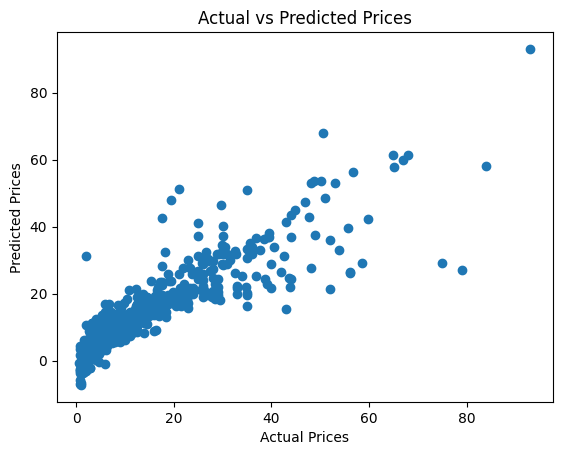

In [9]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")
plt.show()

In [10]:
train

,Year,Mileage,Engine,Power,Name_Audi A3 35 TDI Attraction,Name_Audi A3 35 TDI Premium,Name_Audi A4 1.8 TFSI,Name_Audi A4 2.0 TDI,Name_Audi A4 2.0 TDI 177 Bhp Premium Plus,Name_Audi A4 2.0 TDI 177 Bhp Technology Edition,...,Location_Kochi,Location_Kolkata,Location_Mumbai,Location_Pune,Fuel_Type_Electric,Fuel_Type_Petrol,Transmission_Manual,Owner_Type_Fourth & Above,Owner_Type_Second,Owner_Type_Third
0,2017,23.84,1199.0,84.00,False,False,False,False,False,False,...,False,False,False,False,False,True,True,False,False,False
1,2017,18.49,1493.0,100.00,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
2,2014,15.00,1598.0,103.52,False,False,False,False,False,False,...,False,False,True,False,False,True,True,False,False,False
3,2007,17.20,1396.0,53.50,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,True,False
4,2013,21.02,1248.0,88.76,False,False,False,False,False,False,...,False,False,True,False,False,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3745,2009,11.00,2993.0,235.00,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3746,2012,11.79,2179.0,120.00,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3747,2007,18.90,998.0,67.10,False,False,False,False,False,False,...,False,False,False,False,False,True,True,False,False,False
3748,2014,20.45,1461.0,83.80,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
